In [ ]:
!pip install tensorflow tensorflow-datasets matplotlib seaborn pillow

In [ ]:
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.metrics import confusion_matrix, classification_report
import PIL
import warnings
warnings.filterwarnings('ignore')

In [ ]:
dataset_name = "plant_village"
(ds_train, ds_test), ds_info = tfds.load(
    dataset_name,
    split=['train[:80%]', 'train[80%:]'],
    as_supervised=True,
    with_info=True
)

class_names = ds_info.features['label'].names
num_classes = len(class_names)
print(f"Number of classes: {num_classes}")
print(f"Class names: {class_names[:5]}... (showing first 5)")


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/plant_village/incomplete.8FP56F_1.0.2/plant_village-train.tfrecord*...:   …

Dataset plant_village downloaded and prepared to /root/tensorflow_datasets/plant_village/1.0.2. Subsequent calls will reuse this data.
Number of classes: 38
Class names: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy']... (showing first 5)


In [ ]:
IMG_SIZE = 224
BATCH_SIZE = 32

def preprocess_train(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, 0.2)
    image = tf.cast(image, tf.float32) / 255.0
    label = tf.one_hot(label, num_classes)
    return image, label

def preprocess_test(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.cast(image, tf.float32) / 255.0
    label = tf.one_hot(label, num_classes)
    return image, label

train_ds = ds_train.map(preprocess_train, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = ds_test.map(preprocess_test, num_parallel_calls=tf.data.AUTOTUNE)

train_ds = train_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [ ]:
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
base_model.trainable = False   # freeze base

inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)
model = tf.keras.Model(inputs, outputs)

model.compile(optimizer=tf.keras.optimizers.Adam(), # Explicitly create a new optimizer instance
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 38)             │        77,862 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,665,574 (90.28 MB)

 Trainable params: 77,862 (304.15 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1)

# ModelCheckpoint: save the best model based on val_accuracy
checkpoint = ModelCheckpoint('best_plant_disease_model.h5',
                             monitor='val_accuracy',
                             mode='max',
                             save_best_only=True,
                             verbose=1)

# Optional: ReduceLROnPlateau (reduces LR when val_loss plateaus)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=1e-6, verbose=1)

callbacks = [early_stop, checkpoint, reduce_lr]

In [ ]:
history = model.fit(train_ds,
                    epochs=12,          # more epochs, early stopping will cut off
                    validation_data=test_ds,
                    callbacks=callbacks,
                    verbose=1)

Epoch 1/12
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.1422 - loss: 3.3004
Epoch 1: val_accuracy improved from None to 0.22070, saving model to best_plant_disease_model.h5



Epoch 1: finished saving model to best_plant_disease_model.h5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 170s 108ms/step - accuracy: 0.1836 - loss: 3.1472 - val_accuracy: 0.2207 - val_loss: 2.8862 - learning_rate: 0.0010
Epoch 2/12
1357/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.2500 - loss: 2.8931
Epoch 2: val_accuracy improved from 0.22070 to 0.28423, saving model to best_plant_disease_model.h5



Epoch 2: finished saving model to best_plant_disease_model.h5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 141s 104ms/step - accuracy: 0.2610 - loss: 2.8412 - val_accuracy: 0.2842 - val_loss: 2.6787 - learning_rate: 0.0010
Epoch 3/12
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.2875 - loss: 2.7249
Epoch 3: val_accuracy improved from 0.28423 to 0.32953, saving model to best_plant_disease_model.h5



Epoch 3: finished saving model to best_plant_disease_model.h5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 145s 107ms/step - accuracy: 0.2941 - loss: 2.6908 - val_accuracy: 0.3295 - val_loss: 2.5432 - learning_rate: 0.0010
Epoch 4/12
1357/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.3095 - loss: 2.6071
Epoch 4: val_accuracy improved from 0.32953 to 0.34536, saving model to best_plant_disease_model.h5



Epoch 4: finished saving model to best_plant_disease_model.h5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 146s 108ms/step - accuracy: 0.3154 - loss: 2.5830 - val_accuracy: 0.3454 - val_loss: 2.4456 - learning_rate: 0.0010
Epoch 5/12
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.3319 - loss: 2.5154
Epoch 5: val_accuracy improved from 0.34536 to 0.36544, saving model to best_plant_disease_model.h5


...


Epoch 7: finished saving model to best_plant_disease_model.h5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 146s 107ms/step - accuracy: 0.3617 - loss: 2.3823 - val_accuracy: 0.3926 - val_loss: 2.2413 - learning_rate: 0.0010
Epoch 8/12
1357/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.3677 - loss: 2.3456
Epoch 8: val_accuracy improved from 0.39260 to 0.40586, saving model to best_plant_disease_model.h5



Epoch 8: finished saving model to best_plant_disease_model.h5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 210s 113ms/step - accuracy: 0.3709 - loss: 2.3365 - val_accuracy: 0.4059 - val_loss: 2.1911 - learning_rate: 0.0010
Epoch 9/12
1357/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.3778 - loss: 2.2989
Epoch 9: val_accuracy did not improve from 0.40586
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 143s 105ms/step - accuracy: 0.3810 - loss: 2.2927 - val_accuracy: 0.4047 - val_loss: 2.1517 - learning_rate: 0.0010
Epoch 10/12
1357/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.3861 - loss: 2.2605
Epoch 10: val_accuracy improved from 0.40586 to 0.41387, saving model to best_plant_disease_model.h5



Epoch 10: finished saving model to best_plant_disease_model.h5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 146s 107ms/step - accuracy: 0.3878 - loss: 2.2562 - val_accuracy: 0.4139 - val_loss: 2.1151 - learning_rate: 0.0010
Epoch 11/12
1357/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.3900 - loss: 2.2314
Epoch 11: val_accuracy improved from 0.41387 to 0.42538, saving model to best_plant_disease_model.h5



Epoch 11: finished saving model to best_plant_disease_model.h5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 147s 108ms/step - accuracy: 0.3928 - loss: 2.2269 - val_accuracy: 0.4254 - val_loss: 2.0773 - learning_rate: 0.0010
Epoch 12/12
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.3950 - loss: 2.2052
Epoch 12: val_accuracy improved from 0.42538 to 0.42740, saving model to best_plant_disease_model.h5



Epoch 12: finished saving model to best_plant_disease_model.h5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 147s 108ms/step - accuracy: 0.3986 - loss: 2.2000 - val_accuracy: 0.4274 - val_loss: 2.0561 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 12.


In [ ]:
model.load_weights('best_plant_disease_model.h5')
print("Loaded best model weights.")

Loaded best model weights.


In [ ]:
test_loss, test_acc = model.evaluate(test_ds, verbose=0)
print(f"\nTest Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")


Test Accuracy: 0.4274
Test Loss: 2.0561


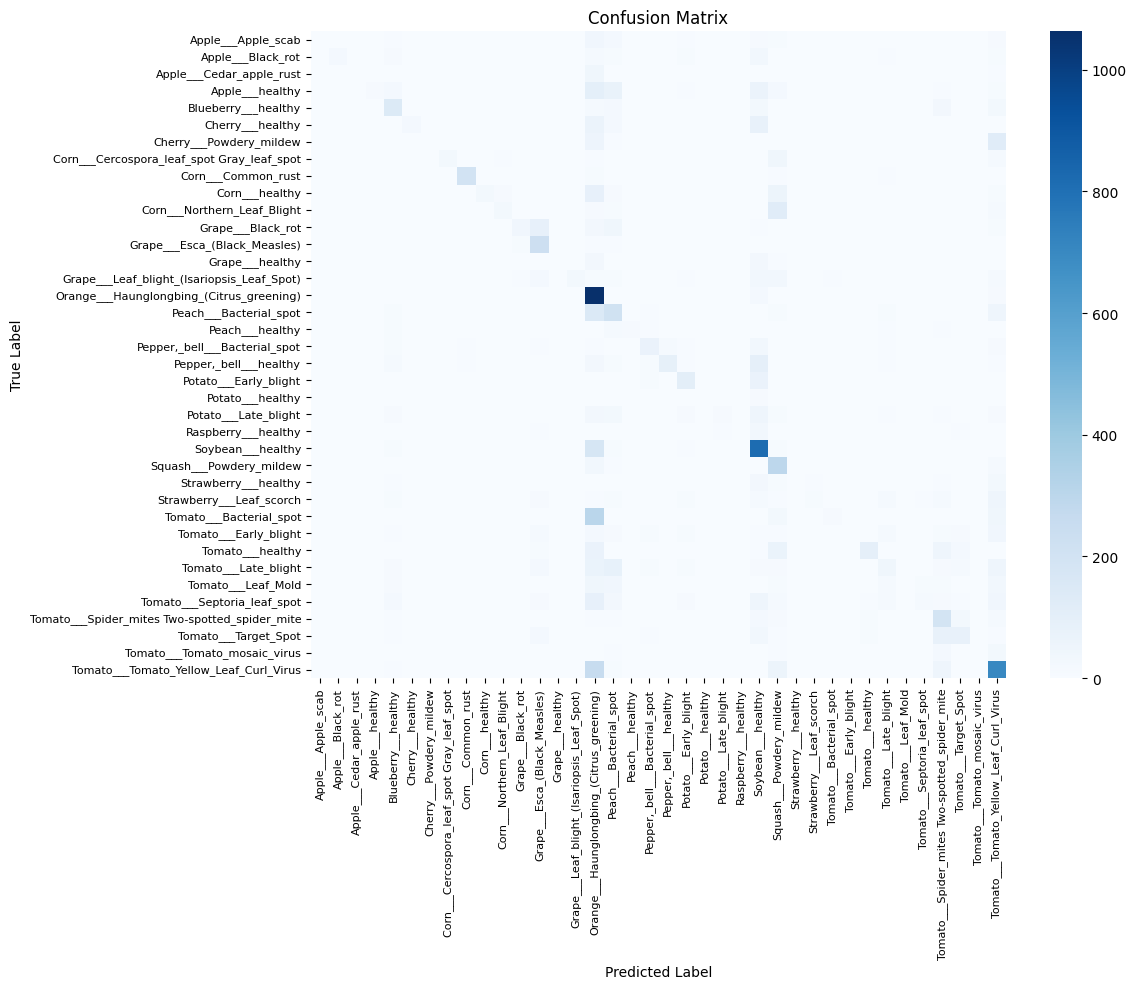


Classification Report:
                                               precision    recall  f1-score   support

                           Apple___Apple_scab     0.0000    0.0000    0.0000       129
                            Apple___Black_rot     0.9130    0.1364    0.2373       154
                     Apple___Cedar_apple_rust     0.0000    0.0000    0.0000        54
                              Apple___healthy     0.7222    0.0383    0.0728       339
                          Blueberry___healthy     0.3799    0.4932    0.4292       292
                             Cherry___healthy     0.5714    0.1231    0.2025       195
                      Cherry___Powdery_mildew     0.3333    0.0100    0.0193       201
   Corn___Cercospora_leaf_spot Gray_leaf_spot     0.6279    0.2500    0.3576       108
                           Corn___Common_rust     0.8826    0.8494    0.8657       239
                               Corn___healthy     0.9355    0.1300    0.2283       223
                  

In [ ]:
y_true = []
y_pred = []

for images, labels in test_ds:
    # labels are one-hot encoded; convert back to integer indices
    true_labels = tf.argmax(labels, axis=1).numpy()
    preds = model.predict(images, verbose=0)
    pred_labels = np.argmax(preds, axis=1)

    y_true.extend(true_labels)
    y_pred.extend(pred_labels)

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot confusion matrix (optional, but helps visualisation)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=False, cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=90, fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

# Print classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

In [ ]:
def predict_plant_disease(img_path):
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = img_array / 255.0
    predictions = model.predict(img_array, verbose=0)
    predicted_class_index = np.argmax(predictions[0])
    confidence = np.max(predictions[0])
    return class_names[predicted_class_index], confidence


--- Upload a leaf image to test ---


Saving Screenshot 2026-04-08 144859.png to Screenshot 2026-04-08 144859.png

Image: Screenshot 2026-04-08 144859.png


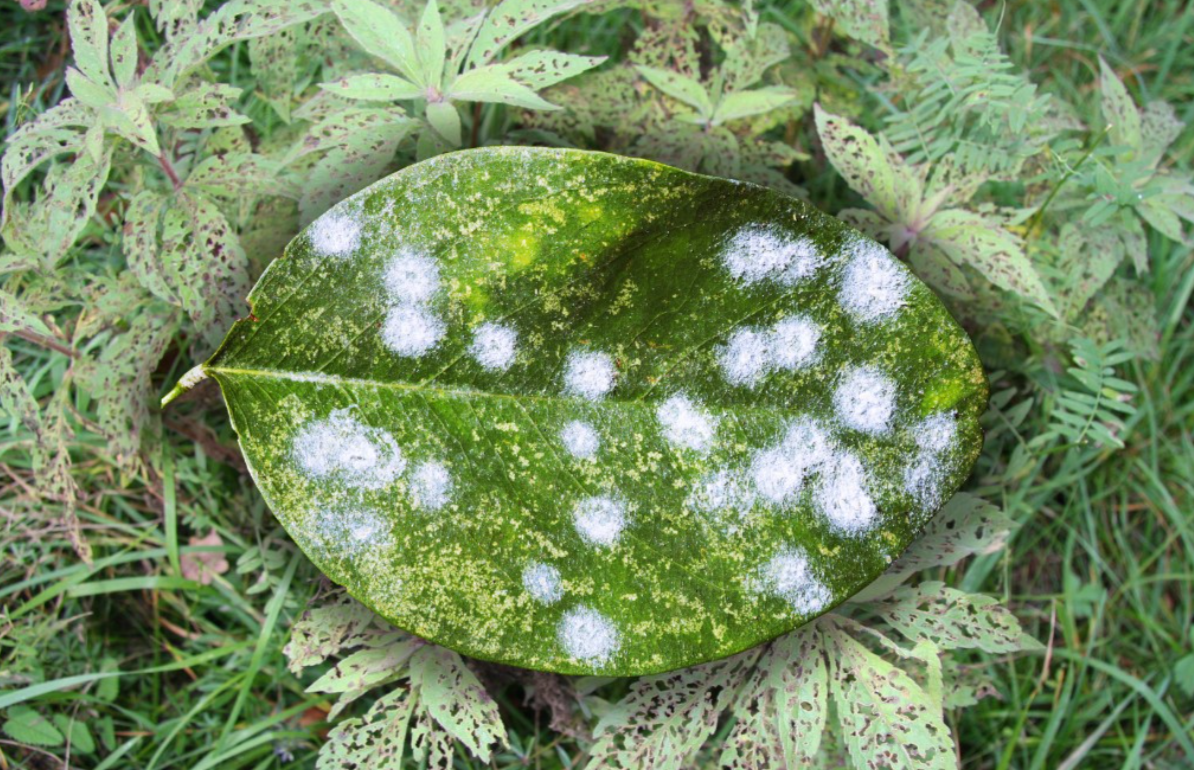

Predicted Disease: Pepper,_bell___Bacterial_spot
Confidence: 0.73


In [ ]:
from google.colab import files
from IPython.display import Image, display

print("\n--- Upload a leaf image to test ---")
uploaded = files.upload()

for filename in uploaded.keys():
    print(f"\nImage: {filename}")
    display(Image(filename))
    predicted_disease, confidence = predict_plant_disease(filename)
    print(f"Predicted Disease: {predicted_disease}")
    print(f"Confidence: {confidence:.2f}")